In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer
from scipy.signal import find_peaks 
from imblearn.over_sampling import SMOTE


from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import os
import seaborn as sns
from statistics import mean

## Functions:

In [8]:
os.listdir(rawData)

NameError: name 'rawData' is not defined

In [6]:

chunkSize = 12

def extractData(file_path):
    data = []
    start_processing = False
    is_frustrated = 0
    ratID = 1

    with open(file_path, 'r') as file:
        lines = file.readlines()

    for line in lines:
        if "Subject" in line: 
            if "L" in line: 
                ratID = 2
        if "EXT" in line:
            is_frustrated = 1
        
        if "P:" in line:
            start_processing = True
            continue
        
        if start_processing:
            if len(line) > 1 and line[0].isalpha() and line[1] == ':':
                break
            if not line:
                break
            parts = line.split()
            if len(parts) > 1:
                numbers = parts[1:]
                data.extend(map(float, numbers))

    data.append(is_frustrated)
    data.append(ratID)
    return data

def lessThan5(data): 
    return [x if x >= 5 else 0 for x in data]

def process_data(data):

    bar_presses = []
    current_press = []
    hasLargeVal = False
    for value in data:
        if value >= 5.0:
            current_press.append(value)
            if value >= 20: #change to 20 
                hasLargeVal = True 
        elif current_press:
            if hasLargeVal: 
                bar_presses.append(current_press)
            current_press = []
            hasLargeVal = False 
    if current_press:
        bar_presses.append(current_press)
    return bar_presses

def process_file(file_path):
    data = extractData(file_path)
    rat_id = data[-1]
    is_frustrated = data[-2]
    data = data[:-2]
    data = lessThan5(data)
    bar_presses = process_data(data)
    return rat_id, is_frustrated, bar_presses



def filter_presses(bar_presses):
    return [press for press in bar_presses if len(press) >= 12]

def calculate_max_and_mean(filtered_presses):
    max_press = [max(press) for press in filtered_presses]
    mean_press = [np.mean(press) for press in filtered_presses]
    return max_press, mean_press

def calculate_average_force(filtered_presses):
    max_length = max(len(press) for press in filtered_presses)
    average_force = np.zeros(max_length)
    count = np.zeros(max_length)
        
    for press in filtered_presses:
        for i, force in enumerate(press):
            average_force[i] += force
            count[i] += 1

    average_force = np.divide(average_force, count, out=np.zeros_like(average_force), where=count!=0)
    return average_force

def calculate_peak_durations(bar_press_forces, threshold):
    threshold = 10
    peaks, _ = find_peaks(bar_press_forces)
    peak_durations = []
    
    for peak in peaks:
        peak_value = bar_press_forces[peak]
        lower_bound = peak_value - threshold
        upper_bound = peak_value + threshold
        
        # Find the start of the peak
        start = peak
        while start > 0 and bar_press_forces[start] >= lower_bound:
            start -= 1
        
        # Find the end of the peak
        end = peak
        while end < len(bar_press_forces) - 1 and bar_press_forces[end] >= lower_bound:
            end += 1
        
        # Calculate duration
        duration = end - start
        peak_durations.append(duration)
    
    return peak_durations

files = [
    "/Users/bacluix/Documents/rat-model/data/!2024-06-04_13h24m.Subject WT L", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-04_13h24m.Subject WT RR", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-05_15h23m.Subject WT RR",
    "/Users/bacluix/Documents/rat-model/data/!2024-06-05_15h24m.Subject WT L", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-06_19h18m.Subject WT 1 RR", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-06_19h18m.Subject WT 2 L", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-09_13h22m.Subject WT L", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-09_13h22m.Subject WT RR", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-09_20h56m.Subject WT 1 RR", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-09_20h57m.Subject WT 2 L", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-10_12h49m.Subject WT L", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-10_12h49m.Subject WT RR", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-10_13h06m.Subject WT L", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-10_13h06m.Subject WT RR", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-10_18h04m.Subject WT 1 RR", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-10_18h04m.Subject WT 2 L", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-10_20h45m.Subject WT 1 RR", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-10_20h45m.Subject WT 2 L", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-10_22h19m.Subject WT 1 RR", 
    "/Users/bacluix/Documents/rat-model/data/!2024-06-10_22h19m.Subject WT 2 L"
] 

all_data = []

for file in files:
    ratid, frustration, data = process_file(file)
    all_data.append([ratid, frustration, data])

df = pd.DataFrame(all_data, columns=['id', 'frustration', 'data'])
df

,id,frustration,data
0,2,1,"[[11.475, 10.498, 10.01, 11.23, 14.648, 18.555..."
1,1,1,"[[6.592, 11.963, 18.311, 24.414, 30.029, 35.15..."
2,1,1,"[[12.695, 14.404, 15.869, 17.09, 18.311, 19.77..."
3,2,1,"[[23.193, 30.029, 32.471, 30.029, 24.17, 17.82..."
4,1,1,"[[22.461, 24.17, 24.902, 25.146, 25.391, 25.14..."
5,2,1,"[[34.668, 42.48, 48.34, 50.049, 46.875, 39.307..."
6,2,1,"[[6.836, 14.16, 21.973, 28.32, 31.982, 32.959,..."
7,1,1,"[[15.381, 20.996, 26.367, 31.006, 34.18, 36.37..."
8,1,0,"[[20.752, 20.752, 20.996, 21.973, 23.438, 25.3..."
9,2,0,"[[28.564, 31.982, 34.18, 36.377, 39.551, 43.45..."


In [ ]:
nf10 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-09_20h57m.Subject WT 2 L"
nf11 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-09_20h56m.Subject WT 1 RR"
nf12 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-09_17h53m.Subject WT RR"
nf13 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-09_17h53m.Subject WT L"
nf14 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-09_15h33m.Subject WT RR"
nf15 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-09_15h33m.Subject WT L"
nf16 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-09_13h01m.Subject WT RR"
nf17 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-09_13h01m.Subject WT L"
nf18 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-06_21h25m.Subject WT 2 L"
nf19 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-06_21h25m.Subject WT 1 RR"
nf20 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-06_14h51m.Subject WT RR"
nf21 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-06_14h51m.Subject WT L"
nf22 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-06_13h12m.Subject WT RR"
nf23 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-06_13h12m.Subject WT L"
nf24 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-06_12h53m.Subject WT RR"
nf25 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-06_12h53m.Subject WT L"
nf26 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-05_23h08m.Subject WT 2 L"
nf27 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-05_23h07m.Subject WT 1 RR"
nf28 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-05_17h14m.Subject WT RR"
nf29 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-05_17h14m.Subject WT L"
nf30 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-05_13h38m.Subject WT RR"
nf31 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-05_13h38m.Subject WT L"
nf32 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-05_13h17m.Subject WT RR"
nf33 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-05_13h17m.Subject WT L"
nf34 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-04_21h44m.Subject WT 2 L"
nf35 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-04_21h44m.Subject WT 1 RR"
nf36 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-04_17h43m.Subject WT RR"
nf37 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-04_17h43m.Subject WT L"
nf38 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-04_15h31m.Subject WT RR"
nf39 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-04_15h31m.Subject WT L"
nf40 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-04_13h05m.Subject WT RR"
nf41 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-04_13h05m.Subject WT L"

## File Path and Count (Unfiltered)

In [1979]:
nf1  = "/Users/bacluix/Downloads/R25 DATA/!2024-06-10_22h19m.Subject WT 2 L"
nf2 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-10_22h19m.Subject WT 1 RR"
nf3 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-10_20h45m.Subject WT 2 L"
nf4 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-10_20h45m.Subject WT 1 RR"
nf5 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-10_18h04m.Subject WT 1 RR"
nf6 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-10_13h06m.Subject WT RR"
nf7 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-10_13h06m.Subject WT L"
nf8 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-10_12h49m.Subject WT RR"
nf9 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-10_12h49m.Subject WT L"
f= "/Users/bacluix/Downloads/R25 DATA/!2024-06-10_18h04m.Subject WT 2 L"
f1 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-09_13h22m.Subject WT RR"
f2 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-09_13h22m.Subject WT L"
f3 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-06_19h18m.Subject WT 2 L"
f4 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-06_19h18m.Subject WT 1 RR"
f5 = '/Users/bacluix/Downloads/R25 DATA/!2024-06-05_15h24m.Subject WT L'
f6 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-05_15h23m.Subject WT RR"
f7 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-04_13h24m.Subject WT RR"
f8 = "/Users/bacluix/Downloads/R25 DATA/!2024-06-04_13h24m.Subject WT L"
files = [nf1, nf2, nf3, nf4, nf5,nf6,nf7,nf8,nf9,f,f1,f2,f3,f4,f5,f6,f7,f8]

f20 = process_data(lessThan5(extractData(f)))
f201 = process_data(lessThan5(extractData(f1)))
f202 = process_data(lessThan5(extractData(f2)))
f203 = process_data(lessThan5(extractData(f3)))
f204 = process_data(lessThan5(extractData(f4)))
f205 = process_data(lessThan5(extractData(f5)))
f206 = process_data(lessThan5(extractData(f6)))
f207 = process_data(lessThan5(extractData(f7)))
f208 = process_data(lessThan5(extractData(f8)))

nf20 = process_data(lessThan5(extractData(nf1)))
nf120 = process_data(lessThan5(extractData(nf2)))
nf220 = process_data(lessThan5(extractData(nf3)))
nf320 = process_data(lessThan5(extractData(nf4)))
nf420 = process_data(lessThan5(extractData(nf5)))
nf520 = process_data(lessThan5(extractData(nf6)))
nf620 = process_data(lessThan5(extractData(nf7)))
nf720 = process_data(lessThan5(extractData(nf8)))
nf820 = process_data(lessThan5(extractData(nf9)))


## Duration for Each Bar Press and Mean Duration

In [1980]:
def calculate_peak_durations(bar_press_forces, threshold):
    threshold = 10
    peaks, _ = find_peaks(bar_press_forces)
    peak_durations = []
    
    for peak in peaks:
        peak_value = bar_press_forces[peak]
        lower_bound = peak_value - threshold
        upper_bound = peak_value + threshold
        
        # Find the start of the peak
        start = peak
        while start > 0 and bar_press_forces[start] >= lower_bound:
            start -= 1
        
        # Find the end of the peak
        end = peak
        while end < len(bar_press_forces) - 1 and bar_press_forces[end] >= lower_bound:
            end += 1
        
        # Calculate duration
        duration = end - start
        peak_durations.append(duration)
    
    return peak_durations


In [1981]:
countF1 = [] 
countF2 = [] 
nonF1 = [] 
nonF2 = [] 

maxF1 = [] 
maxF2 = [] 
maxNon1 = [] 
maxNon2 = [] 

peaksF1 = [] 
numpeaksf1 = [] 
peaksF2 = [] 
numpeaksf2 = [] 
peaksNf1 =  [] 
numpeaksnf1 = []
peaksNf2 = [] 
numpeaksnf2 = [] 

durf1 = [] 
durf2 = [] 
durnf1 = [] 
durnf2 = []
frustrated2 = [arr for arr in frustrated2 if len(arr) < 400]

for array in frustrated1: 
    countF1.append(len(array))
    maxF1.append(max(array))
    peaks, _ = find_peaks(array) 
    peaksF1.append(peaks)
    numpeaksf1.append(len(peaks))
    durf1.append((max(calculate_peak_durations(array, 10))))

for array2 in frustrated2: 
    countF2.append(len(array2))
    maxF2.append(max(array2))
    peaks, _ = find_peaks(array2) 
    peaksF2.append(peaks)
    numpeaksf2.append(len(peaks))
    durf2.append((max(calculate_peak_durations(array2, 10))))
    
for array3 in nonFrustrated1: 
    a = calculate_peak_durations(array3, 10) 
    if a:
        max_peak_duration = max(a)
        durnf1.append(max_peak_duration)
    else: 
        durnf1.append(0)
    nonF1.append(len(array3))
    maxNon1.append(max(array3))
    peaks, _ = find_peaks(array3) 
    peaksNf1.append(peaks)
    numpeaksnf1.append(len(peaks))

for array4 in nonFrustrated2: 
    nonF2.append(len(array4))
    maxNon2.append(max(array4))
    peaks, _ = find_peaks(array4) 
    peaksNf2.append(peaks)
    numpeaksnf2.append(len(peaks))
    durnf2.append((max(calculate_peak_durations(array4, 10))))

print(mean(numpeaksnf2))
print(mean(numpeaksf2))

1.4
1.8571428571428572


In [1982]:
def plot_arrays_in_batches(arrays, lower_threshold, upper_threshold, batch_size=10):
    num_arrays = len(arrays)
    num_batches = (num_arrays + batch_size - 1) // batch_size  # Calculate number of batches
    
    for batch_index in range(num_batches):
        plt.figure(figsize=(12, 6))
        plt.title(f'Arrays with max value between {lower_threshold} and {upper_threshold} - Batch {batch_index + 1}')
        plt.xlabel('Time (s) ')
        plt.ylabel('Force (grams)')
        plt.grid(True)
        
        start_index = batch_index * batch_size
        end_index = min((batch_index + 1) * batch_size, num_arrays)
        
        for arr in arrays[start_index:end_index]:
            max_value = np.max(arr)
            if lower_threshold <= max_value <= upper_threshold:
                plt.plot(arr, label=f'Max: {max_value}')
        
        plt.ylim(0) 
        plt.xlim(0) 
        plt.legend()
        plt.show()

In [1983]:
#barPressDuration
f1count = [] 
f2count = [] 
f3count = [] 
f4count = [] 
f5count = [] 
f6count = [] 
f7count = []
f8count = []
f8count = []
f9count = []
nf1count = [] 
nf2count = [] 
nf3count = [] 
nf4count = [] 
nf5count = [] 
nf6count = [] 
nf7count = []
nf8count = []
nf9count = [] 
 
#maxPress
f1max = [] 
f2max = [] 
f3max = [] 
f4max = [] 
f5max = [] 
f6max = [] 
f7max = []
f8max = []
f9max = [] 
nf1max = [] 
nf2max = [] 
nf3max = [] 
nf4max = [] 
nf5max = [] 
nf6max = [] 
nf7max = []
nf8max = []
nf9max = [] 

#numPeaks 
f1peaks = [] 
f2peaks = [] 
f3peaks = [] 
f4peaks = [] 
f5peaks = [] 
f6peaks = [] 
f7peaks = []
f8peaks = []
f9peaks = [] 

nf1peaks = [] 
nf2peaks = [] 
nf3peaks = [] 
nf4peaks = [] 
nf5peaks = []
nf6peaks = [] 
nf7peaks = [] 
nf8peaks = []
nf9peaks = [] 

#peakDuration  

f1dur = [] 
f2dur = [] 
f3dur = [] 
f4dur = [] 
f5dur = [] 
f6dur = [] 
f7dur = []
f8dur = []
f9dur = [] 

nf1dur = [] 
nf2dur = [] 
nf3dur = [] 
nf4dur = [] 
nf5dur = [] 
nf6dur = [] 
nf7dur = []
nf8dur = []
nf9dur = [] 

for array in f20: 
    f1count.append(len(array))
    f1max.append(max(array))
    peaks, _ = find_peaks(array) 
    f1peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        f1dur.append(max_peak_duration)
    else: 
        f1dur.append(0)

for array in f201: 
    f2count.append(len(array))
    f2max.append(max(array))
    peaks, _ = find_peaks(array) 
    f2peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        f2dur.append(max_peak_duration)
    else: 
        f2dur.append(0)

for array in f202: 
    f3count.append(len(array))
    f3max.append(max(array))
    peaks, _ = find_peaks(array) 
    f3peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        f3dur.append(max_peak_duration)
    else: 
        f3dur.append(0)

for array in f203: 
    f4count.append(len(array))
    f4max.append(max(array))
    peaks, _ = find_peaks(array) 
    f4peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        f4dur.append(max_peak_duration)
    else: 
        f4dur.append(0)

for array in f204: 
    f5count.append(len(array))
    f5max.append(max(array))
    peaks, _ = find_peaks(array) 
    f5peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        f5dur.append(max_peak_duration)
    else: 
        f5dur.append(0)

for array in f205: 
    f6count.append(len(array))
    f6max.append(max(array))
    peaks, _ = find_peaks(array) 
    f6peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        f6dur.append(max_peak_duration)
    else: 
        f6dur.append(0)

for array in f206: 
    f7count.append(len(array))
    f7max.append(max(array))
    peaks, _ = find_peaks(array) 
    f7peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        f7dur.append(max_peak_duration)
    else: 
        f7dur.append(0)

for array in f207: 
    f8count.append(len(array))
    f8max.append(max(array))
    peaks, _ = find_peaks(array) 
    f8peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        f8dur.append(max_peak_duration)
    else: 
        f8dur.append(0)

for array in f208: 
    f9count.append(len(array))
    f9max.append(max(array))
    peaks, _ = find_peaks(array) 
    f9peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        f9dur.append(max_peak_duration)
    else: 
        f9dur.append(0)

for array in nf20: 
    nf1count.append(len(array))
    nf1max.append(max(array))
    peaks, _ = find_peaks(array) 
    nf1peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        nf1dur.append(max_peak_duration)
    else: 
        nf1dur.append(0)

for array in nf120: 
    nf2count.append(len(array))
    nf2max.append(max(array))
    peaks, _ = find_peaks(array) 
    nf2peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        nf2dur.append(max_peak_duration)
    else: 
        nf2dur.append(0)

for array in nf220: 
    nf3count.append(len(array))
    nf3max.append(max(array))
    peaks, _ = find_peaks(array) 
    nf3peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        nf3dur.append(max_peak_duration)
    else: 
        nf3dur.append(0)

for array in nf320: 
    nf4count.append(len(array))
    nf4max.append(max(array))
    peaks, _ = find_peaks(array) 
    nf4peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        nf4dur.append(max_peak_duration)
    else: 
        nf4dur.append(0)

for array in nf420: 
    nf5count.append(len(array))
    nf5max.append(max(array))
    peaks, _ = find_peaks(array) 
    nf5peaks.append(len(peaks))
    a = calculate_peak_durations(array, 20) 
    if a:
        max_peak_duration = max(a)
        nf5dur.append(max_peak_duration)
    else: 
        nf5dur.append(0)

for array in nf520: 
    nf6count.append(len(array))
    nf6max.append(max(array))
    peaks, _ = find_peaks(array) 
    nf6peaks.append(len(peaks))
    a = calculate_peak_durations(array, 10) 
    if a:
        max_peak_duration = max(a)
        nf6dur.append(max_peak_duration)
    else: 
        nf6dur.append(0)

for array in nf620: 
    nf7count.append(len(array))
    nf7max.append(max(array))
    peaks, _ = find_peaks(array) 
    nf7peaks.append(len(peaks))
    a = calculate_peak_durations(array, 10) 
    if a:
        max_peak_duration = max(a)
        nf7dur.append(max_peak_duration)
    else: 
        nf7dur.append(0)

for array in nf720: 
    nf8count.append(len(array))
    nf8max.append(max(array))
    peaks, _ = find_peaks(array) 
    nf8peaks.append(len(peaks))
    a = calculate_peak_durations(array, 10) 
    if a:
        max_peak_duration = max(a)
        nf8dur.append(max_peak_duration)
    else: 
        nf8dur.append(0)

for array in nf820: 
    nf9count.append(len(array))
    nf9max.append(max(array))
    peaks, _ = find_peaks(array) 
    nf9peaks.append(len(peaks))
    a = calculate_peak_durations(array, 10) 
    if a:
        max_peak_duration = max(a)
        nf9dur.append(max_peak_duration)
    else: 
        nf9dur.append(0)



In [1984]:
data = {
    "barPressDuration": f1count,
    "maxPress": f1max,
    "numberOfPeaks": f1peaks, 
    "maxDuration": f1dur
}

a = pd.DataFrame(data)
a["frustrationState"] = 1
a['rollingAverageBPD'] = a['barPressDuration'].rolling(window=3).mean() 
a['rollingMaxPress'] = a['maxPress'].rolling(window=3).mean()
a = a.dropna() 
num_chunks = len(a) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = a.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

a = pd.DataFrame(chunk_means)


In [1985]:
data1 = {
    "barPressDuration": f2count,
    "maxPress": f2max,
    "numberOfPeaks": f2peaks, 
    "maxDuration": f2dur
}

b = pd.DataFrame(data1)
b["frustrationState"] = 1
b['rollingAverageBPD'] = b['barPressDuration'].rolling(window=3).mean() 
b['rollingMaxPress'] = b['maxPress'].rolling(window=3).mean()
b = b.dropna() 
num_chunks = len(b) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = b.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

b = pd.DataFrame(chunk_means)


In [1986]:
data2 = {
    "barPressDuration": f3count,
    "maxPress": f3max,
    "numberOfPeaks": f3peaks, 
    "maxDuration": f3dur
}

c = pd.DataFrame(data2)
c["frustrationState"] = 1
c['rollingAverageBPD'] = c['barPressDuration'].rolling(window=3).mean() 
c['rollingMaxPress'] = c['maxPress'].rolling(window=3).mean()
c = c.dropna() 
num_chunks = len(c) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = c.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

c = pd.DataFrame(chunk_means)


In [1987]:
data3 = {
    "barPressDuration": f4count,
    "maxPress": f4max,
    "numberOfPeaks": f4peaks, 
    "maxDuration": f4dur
}

d = pd.DataFrame(data3)
d["frustrationState"] = 1
d['rollingAverageBPD'] = d['barPressDuration'].rolling(window=3).mean() 
d['rollingMaxPress'] = d['maxPress'].rolling(window=3).mean()
d = d.dropna() 
num_chunks = len(d) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = d.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

d = pd.DataFrame(chunk_means)
d = d.dropna() 


In [1988]:
data4 = {
    "barPressDuration": f5count,
    "maxPress": f5max,
    "numberOfPeaks": f5peaks, 
    "maxDuration": f5dur
}

e = pd.DataFrame(data4)
e["frustrationState"] = 1
e['rollingAverageBPD'] = e['barPressDuration'].rolling(window=3).mean() 
e['rollingMaxPress'] = e['maxPress'].rolling(window=3).mean()
e = e.dropna() 
num_chunks = len(e) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = e.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

e = pd.DataFrame(chunk_means)
e = e.dropna() 


In [1989]:
data5 = {
    "barPressDuration": f6count,
    "maxPress": f6max,
    "numberOfPeaks": f6peaks, 
    "maxDuration": f6dur
}

f = pd.DataFrame(data5)
f["frustrationState"] = 1
f['rollingAverageBPD'] = f['barPressDuration'].rolling(window=3).mean() 
f['rollingMaxPress'] = f['maxPress'].rolling(window=3).mean()
f = f.dropna() 
num_chunks = len(f) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = f.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

f = pd.DataFrame(chunk_means)
f = f.dropna() 


In [1990]:
data6 = {
    "barPressDuration": f7count,
    "maxPress": f7max,
    "numberOfPeaks": f7peaks, 
    "maxDuration": f7dur
}

g = pd.DataFrame(data6)
g["frustrationState"] = 1
g['rollingAverageBPD'] = g['barPressDuration'].rolling(window=3).mean() 
g['rollingMaxPress'] = g['maxPress'].rolling(window=3).mean()
g = g.dropna() 
num_chunks = len(g) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = g.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

g = pd.DataFrame(chunk_means)
g = g.dropna() 


In [1991]:
data7 = {
    "barPressDuration": f8count,
    "maxPress": f8max,
    "numberOfPeaks": f8peaks, 
    "maxDuration": f8dur
}

h = pd.DataFrame(data7)
h["frustrationState"] = 1
h['rollingAverageBPD'] = h['barPressDuration'].rolling(window=3).mean() 
h['rollingMaxPress'] = h['maxPress'].rolling(window=3).mean()
h = h.dropna() 
num_chunks = len(h) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = h.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

h = pd.DataFrame(chunk_means)
h = h.dropna() 


In [1992]:
data8 = {
    "barPressDuration": f9count,
    "maxPress": f9max,
    "numberOfPeaks": f9peaks, 
    "maxDuration": f9dur
}

j = pd.DataFrame(data8)
j["frustrationState"] = 1
j['rollingAverageBPD'] = j['barPressDuration'].rolling(window=3).mean() 
j['rollingMaxPress'] = j['maxPress'].rolling(window=3).mean()
j = j.dropna() 
num_chunks = len(j) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = j.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

j = pd.DataFrame(chunk_means)
j = j.dropna() 


In [1993]:
data = {
    "barPressDuration": nf1count,
    "maxPress": nf1max,
    "numberOfPeaks": nf1peaks, 
    "maxDuration": nf1dur
}

nfDF = pd.DataFrame(data)
nfDF["frustrationState"] = 0
nfDF['rollingAverageBPD'] = nfDF['barPressDuration'].rolling(window=3).mean() 
nfDF['rollingMaxPress'] = nfDF['maxPress'].rolling(window=3).mean()
nfDF = nfDF.dropna() 
num_chunks = len(nfDF) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = nfDF.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

k = pd.DataFrame(chunk_means)
k = k.dropna() 


In [1994]:
data = {
    "barPressDuration": nf2count,
    "maxPress": nf2max,
    "numberOfPeaks": nf2peaks, 
    "maxDuration": nf2dur
}

nfDF2 = pd.DataFrame(data)
nfDF2["frustrationState"] = 0
nfDF2['rollingAverageBPD'] = nfDF2['barPressDuration'].rolling(window=3).mean() 
nfDF2['rollingMaxPress'] = nfDF2['maxPress'].rolling(window=3).mean()
nfDF2 = nfDF2.dropna() 
num_chunks = len(nfDF2) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = nfDF2.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

l = pd.DataFrame(chunk_means)
l = l.dropna() 

In [1995]:
data = {
    "barPressDuration": nf3count,
    "maxPress": nf3max,
    "numberOfPeaks": nf3peaks, 
    "maxDuration": nf3dur
}

nfDF3 = pd.DataFrame(data)
nfDF3["frustrationState"] = 0
nfDF3['rollingAverageBPD'] = nfDF3['barPressDuration'].rolling(window=3).mean() 
nfDF3['rollingMaxPress'] = nfDF3['maxPress'].rolling(window=3).mean()
nfDF3 = nfDF3.dropna() 
num_chunks = len(nfDF3) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = nfDF3.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

m = pd.DataFrame(chunk_means)
m = m.dropna() 

In [1996]:
data = {
    "barPressDuration": nf4count,
    "maxPress": nf4max,
    "numberOfPeaks": nf4peaks, 
    "maxDuration": nf4dur
}

nfDF4 = pd.DataFrame(data)
nfDF4["frustrationState"] = 0
nfDF4['rollingAverageBPD'] = nfDF4['barPressDuration'].rolling(window=3).mean() 
nfDF4['rollingMaxPress'] = nfDF4['maxPress'].rolling(window=3).mean()
nfDF4 = nfDF4.dropna() 
num_chunks = len(nfDF4) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = nfDF4.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

n = pd.DataFrame(chunk_means)
n = n.dropna() 

In [1997]:
data = {
    "barPressDuration": nf5count,
    "maxPress": nf5max,
    "numberOfPeaks": nf5peaks, 
    "maxDuration": nf5dur
}

nfDF5 = pd.DataFrame(data)
nfDF5["frustrationState"] = 0
nfDF5['rollingAverageBPD'] = nfDF5['barPressDuration'].rolling(window=3).mean() 
nfDF5['rollingMaxPress'] = nfDF5['maxPress'].rolling(window=3).mean()
nfDF5 = nfDF5.dropna() 
num_chunks = len(nfDF5) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = nfDF5.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

o = pd.DataFrame(chunk_means)
o = o.dropna() 

In [1998]:
data = {
    "barPressDuration": nf6count,
    "maxPress": nf6max,
    "numberOfPeaks": nf6peaks, 
    "maxDuration": nf6dur
}

nfDF6 = pd.DataFrame(data)
nfDF6["frustrationState"] = 0
nfDF6['rollingAverageBPD'] = nfDF6['barPressDuration'].rolling(window=3).mean() 
nfDF6['rollingMaxPress'] = nfDF6['maxPress'].rolling(window=3).mean()
nfDF6 = nfDF6.dropna() 
num_chunks = len(nfDF6) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = nfDF6.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

p = pd.DataFrame(chunk_means)
p = p.dropna() 

In [1999]:
data = {
    "barPressDuration": nf7count,
    "maxPress": nf7max,
    "numberOfPeaks": nf7peaks, 
    "maxDuration": nf7dur
}

nfDF7 = pd.DataFrame(data)
nfDF7["frustrationState"] = 0
nfDF7['rollingAverageBPD'] = nfDF7['barPressDuration'].rolling(window=3).mean() 
nfDF7['rollingMaxPress'] = nfDF7['maxPress'].rolling(window=3).mean()
nfDF7 = nfDF7.dropna() 
num_chunks = len(nfDF7) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = nfDF7.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

q = pd.DataFrame(chunk_means)
q = q.dropna() 

In [2000]:
data = {
    "barPressDuration": nf8count,
    "maxPress": nf8max,
    "numberOfPeaks": nf8peaks, 
    "maxDuration": nf8dur
}

nfDF8 = pd.DataFrame(data)
nfDF8["frustrationState"] = 0
nfDF8['rollingAverageBPD'] = nfDF8['barPressDuration'].rolling(window=3).mean() 
nfDF8['rollingMaxPress'] = nfDF8['maxPress'].rolling(window=3).mean()
nfDF8 = nfDF8.dropna() 
num_chunks = len(nfDF8) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = nfDF8.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

r = pd.DataFrame(chunk_means)
r = n.dropna() 

In [2001]:
data = {
    "barPressDuration": nf9count,
    "maxPress": nf9max,
    "numberOfPeaks": nf9peaks, 
    "maxDuration": nf9dur
}

nfDF9 = pd.DataFrame(data)
nfDF9["frustrationState"] = 0
nfDF9['rollingAverageBPD'] = nfDF9['barPressDuration'].rolling(window=3).mean() 
nfDF9['rollingMaxPress'] = nfDF9['maxPress'].rolling(window=3).mean()
nfDF9 = nfDF9.dropna() 
num_chunks = len(nfDF9) // chunkSize
chunk_means = []

for i in range(num_chunks + 1):
    chunk = nfDF9.iloc[i * chunkSize:(i + 1) * chunkSize]
    
    mean_values = {}
    for col in chunk.columns:
        if pd.api.types.is_numeric_dtype(chunk[col]):
            mean_values[col] = chunk[col].mean()
        else:
            mean_values[col] = chunk[col].iloc[0]  
    
    chunk_means.append(mean_values)

s = pd.DataFrame(chunk_means)
s = s.dropna() 

In [2002]:
threshold20 = pd.concat([a, b, c, d, e, f, g, h, j, k, l, m, n, o, p, q,r,s], ignore_index=True)
threshold20['barPressDuration_maxPress'] = threshold20['barPressDuration'] * threshold20['maxPress'] #interaction terms 
threshold20['barPressDuration_numberOfPeaks'] = threshold20['barPressDuration'] * threshold20['numberOfPeaks'] #interaction terms
threshold20['maxPress_numberOfPeaks'] = threshold20['maxPress'] * threshold20['numberOfPeaks'] #interaction terms 
threshold20['peaks'] = threshold20['maxDuration'] * threshold20['numberOfPeaks']
threshold20['combinedPeaksWithMaxPress'] = threshold20['peaks'] * threshold20['maxPress']
threshold20 = threshold20.dropna() 
threshold20

,barPressDuration,maxPress,numberOfPeaks,maxDuration,frustrationState,rollingAverageBPD,rollingMaxPress,barPressDuration_maxPress,barPressDuration_numberOfPeaks,maxPress_numberOfPeaks,peaks,combinedPeaksWithMaxPress
0,17.583333,48.563667,1.333333,7.916667,1.0,17.750000,45.261000,853.911139,23.444444,64.751556,10.555556,512.616481
1,105.142857,62.221143,7.857143,94.571429,1.0,84.142857,73.091143,6542.108735,826.122449,488.880408,743.061224,46234.118601
2,106.166667,58.858250,7.000000,96.166667,1.0,101.638889,54.131417,6248.784208,743.166667,412.007750,673.166667,39621.411958
3,167.083333,53.060000,10.166667,158.500000,1.0,175.527778,56.328778,8865.441667,1698.680556,539.443333,1611.416667,85501.768333
4,311.000000,56.518500,18.750000,250.000000,1.0,195.000000,57.047500,17577.253500,5831.250000,1059.721875,4687.500000,264930.468750
5,26.833333,68.196833,1.666667,5.833333,1.0,23.222222,64.968833,1829.948361,44.722222,113.661389,9.722222,663.024769
6,30.666667,47.770250,2.250000,23.666667,1.0,31.000000,49.275778,1464.954333,69.000000,107.483062,53.250000,2543.765812
7,31.333333,82.031000,2.000000,21.000000,1.0,28.777778,66.867333,2570.304667,62.666667,164.062000,42.000000,3445.302000
8,179.200000,45.459100,11.500000,173.200000,1.0,185.266667,45.369567,8146.270720,2060.800000,522.779650,1991.800000,90545.435380
9,25.916667,70.149583,1.583333,11.500000,1.0,24.583333,68.176139,1818.043368,41.034722,111.070174,18.208333,1277.306997


Model 

Logistic Regression Classifier Accuracy: 0.82
Decision Tree Classifier Accuracy: 0.73
Gradient Boosting Classifier Accuracy: 0.91


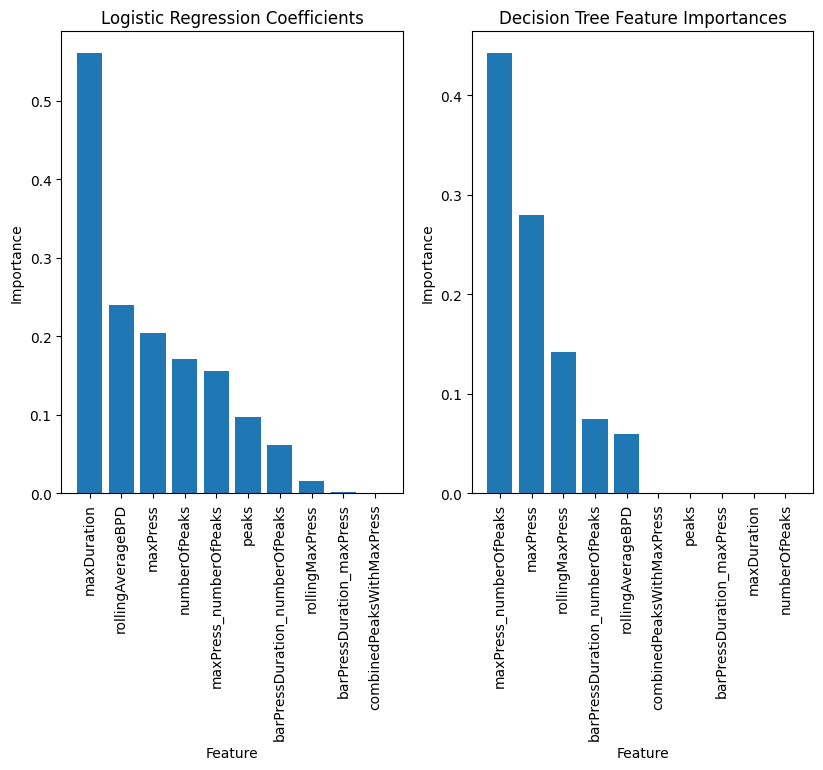

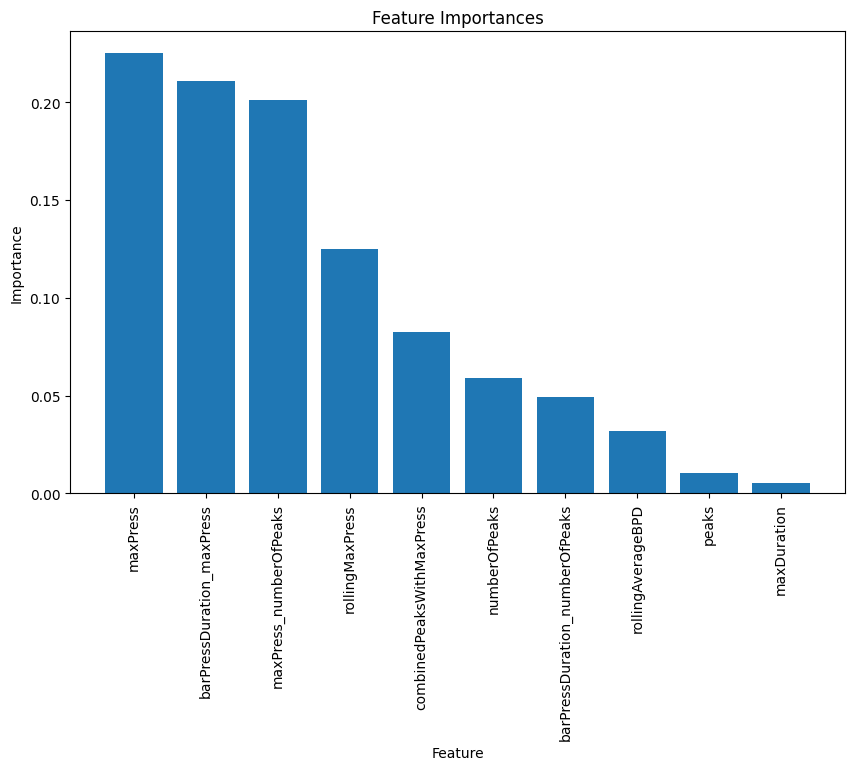

In [2006]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Assuming 'threshold20' is your DataFrame
X = threshold20.drop(columns=['frustrationState', 'barPressDuration'])
y = threshold20['frustrationState']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
model1 = LogisticRegression(max_iter=10000000)
model1.fit(X_train, y_train)
y_pred_log = model1.predict_proba(X_test)
y_pred_log_result = (y_pred_log[:, 1] >= 0.5).astype(int)
accuracy_log = accuracy_score(y_test, y_pred_log_result)
print(f"Logistic Regression Classifier Accuracy: {accuracy_log:.2f}")

# Decision Tree Classifier
model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)
y_decision_tree = model2.predict_proba(X_test)
y_tree_result = (y_decision_tree[:, 1] >= 0.5).astype(int)
accuracy_tree = accuracy_score(y_test, y_tree_result)
print(f"Decision Tree Classifier Accuracy: {accuracy_tree:.2f}")

# Gradient Boosting Classifier
model3 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42)
model3.fit(X_train, y_train)
y_pred_proba_gb = model3.predict_proba(X_test)
y_pred_gb = (y_pred_proba_gb[:, 1] >= 0.5).astype(int)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Classifier Accuracy: {accuracy_gb:.2f}")


feature_names = X.columns

sorted_idx = np.argsort(feature_importances)[::-1]

# Coefficients for Logistic Regression
feature_importances_log = np.abs(model1.coef_[0])
sorted_idx_log = np.argsort(feature_importances_log)[::-1]

# Feature importances for Decision Tree Classifier
feature_importances_tree = model2.feature_importances_
sorted_idx_tree = np.argsort(feature_importances_tree)[::-1]

# Plotting
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.bar(range(len(feature_importances_log)), feature_importances_log[sorted_idx_log], align='center')
plt.xticks(range(len(feature_importances_log)), feature_names[sorted_idx_log], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Logistic Regression Coefficients')

plt.subplot(1, 3, 2)
plt.bar(range(len(feature_importances_tree)), feature_importances_tree[sorted_idx_tree], align='center')
plt.xticks(range(len(feature_importances_tree)), feature_names[sorted_idx_tree], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Decision Tree Feature Importances')


plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importances)), feature_importances[sorted_idx], align='center')
plt.xticks(range(len(feature_importances)), feature_names[sorted_idx], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances')
plt.show()



<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=02e09a89-af54-419b-92c2-8068cac0ef90' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>